In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
courses = [
("AI","DosenA"),("ML","DosenB"),("DB","DosenC"),
("CN","DosenD"),("SE","DosenE"),("OS","DosenF"),
("IR","DosenA"),("NLP","DosenB"),("CV","DosenC"),
("IOT","DosenD"),("HCI","DosenE"),("CyberSec","DosenF"),
("BigData","DosenA"),("DL","DosenB"),("NoSQL","DosenC"),
("Cloud","DosenD"),("UX","DosenE"),("SecEng","DosenF"),
("Agile","DosenA"),("RL","DosenB"),("ETL","DosenC"),
("DevOps","DosenD"),("GameDev","DosenE"),("Blockchain","DosenF")
]

rooms = ["R1","R2","R3","R4"]

timeslots = [
"Senin-08","Senin-10","Senin-13",
"Selasa-08","Selasa-10","Selasa-13",
"Rabu-08","Rabu-10","Rabu-13",
"Kamis-08","Kamis-10","Kamis-13"
]

In [3]:
POP_SIZE = 60
GENERATIONS = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.2

In [4]:
def create_individual():
    return [(random.choice(rooms), random.choice(timeslots)) for _ in courses]

In [5]:
def hitung_konflik(ind):
    konflik = 0

    for i in range(len(ind)):
        for j in range(i+1, len(ind)):

            r1,t1 = ind[i]
            r2,t2 = ind[j]

            d1 = courses[i][1]
            d2 = courses[j][1]

            # konflik ruang
            if r1 == r2 and t1 == t2:
                konflik += 1

            # konflik dosen waktu
            if d1 == d2 and t1 == t2:
                konflik += 1

            # konflik dosen hari
            if d1 == d2 and t1.split("-")[0] == t2.split("-")[0]:
                konflik += 1

    return konflik

In [6]:
def fitness(ind):
    konflik = hitung_konflik(ind)
    return max(0, 100 - konflik)

In [7]:
def selection(pop):
    return sorted(pop, key=lambda x: fitness(x), reverse=True)[:POP_SIZE//2]

In [8]:
def crossover(p1, p2):
    if random.random() < CROSSOVER_RATE:
        point = random.randint(1, len(p1)-2)
        return p1[:point] + p2[point:]
    return p1.copy()

In [9]:
def mutation(ind):
    ind = ind.copy()
    for i in range(len(ind)):
        if random.random() < MUTATION_RATE:
            ind[i] = (random.choice(rooms), random.choice(timeslots))
    return ind

In [10]:
population = [create_individual() for _ in range(POP_SIZE)]

max_fitness_history = []
avg_fitness_history = []

for gen in range(GENERATIONS):

    fitness_values = [fitness(ind) for ind in population]

    max_fitness = max(fitness_values)
    avg_fitness = sum(fitness_values)/len(fitness_values)

    max_fitness_history.append(max_fitness)
    avg_fitness_history.append(avg_fitness)

    print(f"Gen {gen} | Max: {max_fitness} | Avg: {avg_fitness:.2f}")

    selected = selection(population)

    new_pop = selected.copy()

    while len(new_pop) < POP_SIZE:
        p1, p2 = random.sample(selected, 2)
        child = crossover(p1, p2)
        child = mutation(child)
        new_pop.append(child)

    population = new_pop

Gen 0 | Max: 91 | Avg: 81.98
Gen 1 | Max: 91 | Avg: 83.98
Gen 2 | Max: 92 | Avg: 85.53
Gen 3 | Max: 93 | Avg: 86.27
Gen 4 | Max: 93 | Avg: 86.67
Gen 5 | Max: 93 | Avg: 86.83
Gen 6 | Max: 93 | Avg: 87.85
Gen 7 | Max: 93 | Avg: 88.52
Gen 8 | Max: 93 | Avg: 88.02
Gen 9 | Max: 93 | Avg: 88.83
Gen 10 | Max: 93 | Avg: 88.05
Gen 11 | Max: 93 | Avg: 88.77
Gen 12 | Max: 93 | Avg: 89.15
Gen 13 | Max: 93 | Avg: 88.82
Gen 14 | Max: 95 | Avg: 89.37
Gen 15 | Max: 95 | Avg: 89.83
Gen 16 | Max: 95 | Avg: 89.57
Gen 17 | Max: 95 | Avg: 89.80
Gen 18 | Max: 96 | Avg: 90.40
Gen 19 | Max: 96 | Avg: 90.50
Gen 20 | Max: 96 | Avg: 90.42
Gen 21 | Max: 96 | Avg: 90.25
Gen 22 | Max: 96 | Avg: 90.38
Gen 23 | Max: 96 | Avg: 91.02
Gen 24 | Max: 96 | Avg: 90.25
Gen 25 | Max: 96 | Avg: 91.12
Gen 26 | Max: 96 | Avg: 90.37
Gen 27 | Max: 96 | Avg: 89.70
Gen 28 | Max: 96 | Avg: 90.38
Gen 29 | Max: 96 | Avg: 91.02
Gen 30 | Max: 96 | Avg: 90.22
Gen 31 | Max: 97 | Avg: 91.00
Gen 32 | Max: 97 | Avg: 91.45
Gen 33 | Max: 97 | A

In [11]:
best = max(population, key=fitness)
konflik = hitung_konflik(best)

print("\n===== HASIL AKHIR =====")
print("Fitness terbaik :", fitness(best))
print("Jumlah konflik  :", konflik)

print("\nJadwal:\n")

for i in range(len(best)):
    mk, dosen = courses[i]
    ruang, waktu = best[i]
    print(f"{mk} ({dosen}) -> {ruang} | {waktu}")


===== HASIL AKHIR =====
Fitness terbaik : 97
Jumlah konflik  : 3

Jadwal:

AI (DosenA) -> R4 | Senin-10
ML (DosenB) -> R2 | Kamis-10
DB (DosenC) -> R3 | Senin-08
CN (DosenD) -> R4 | Rabu-10
SE (DosenE) -> R3 | Selasa-10
OS (DosenF) -> R1 | Selasa-08
IR (DosenA) -> R4 | Kamis-10
NLP (DosenB) -> R4 | Senin-10
CV (DosenC) -> R3 | Rabu-08
IOT (DosenD) -> R1 | Kamis-10
HCI (DosenE) -> R3 | Kamis-08
CyberSec (DosenF) -> R3 | Senin-10
BigData (DosenA) -> R1 | Rabu-10
DL (DosenB) -> R3 | Rabu-13
NoSQL (DosenC) -> R4 | Selasa-13
Cloud (DosenD) -> R4 | Rabu-13
UX (DosenE) -> R4 | Senin-08
SecEng (DosenF) -> R2 | Rabu-08
Agile (DosenA) -> R2 | Selasa-08
RL (DosenB) -> R2 | Selasa-10
ETL (DosenC) -> R1 | Kamis-13
DevOps (DosenD) -> R2 | Selasa-08
GameDev (DosenE) -> R1 | Rabu-13
Blockchain (DosenF) -> R2 | Kamis-08


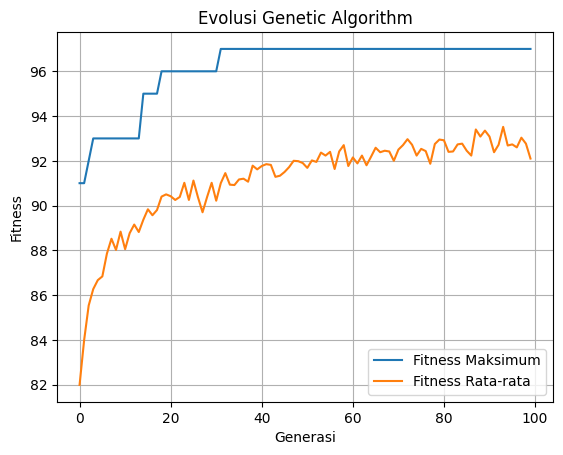

In [12]:
plt.plot(max_fitness_history, label="Fitness Maksimum")
plt.plot(avg_fitness_history, label="Fitness Rata-rata")

plt.title("Evolusi Genetic Algorithm")
plt.xlabel("Generasi")
plt.ylabel("Fitness")
plt.legend()
plt.grid()

plt.show()